In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pysheds.grid import Grid

# Strict Absolute Path Mapping
BASE_DIR = r"C:\Terrain_based_flood_modelling"

# The Fix: Pointing to the 'data' folder, not 'DEM'
DEM_PATH = os.path.join(BASE_DIR, "data", "Gilgit_DEM_Clipped.tif")
HAND_OUT_PATH = os.path.join(BASE_DIR, "data", "gilgit_hand.tif")
STREAM_OUT_PATH = os.path.join(BASE_DIR, "data", "gilgit_streams.tif")

print(f"Checking if file exists: {os.path.exists(DEM_PATH)}")

print("Initializing PySheds Grid...")
grid = Grid.from_raster(DEM_PATH)
dem = grid.read_raster(DEM_PATH)
print("DEM Array successfully loaded into memory.")

Checking if file exists: True
Initializing PySheds Grid...
DEM Array successfully loaded into memory.


c:\Users\taimoor\anaconda3\envs\flood_model\lib\site-packages\pysheds\io.py:134: UserWarning: No `nodata` value detected. Defaulting to 0.
  warnings.warn('No `nodata` value detected. Defaulting to 0.')
c:\Users\taimoor\anaconda3\envs\flood_model\lib\site-packages\pysheds\io.py:134: UserWarning: No `nodata` value detected. Defaulting to 0.
  warnings.warn('No `nodata` value detected. Defaulting to 0.')


In [4]:
print("Filling single-cell pits...")
pit_filled_dem = grid.fill_pits(dem)

print("Filling multi-cell depressions...")
flooded_dem = grid.fill_depressions(pit_filled_dem)

print("Resolving flat regions...")
inflated_dem = grid.resolve_flats(flooded_dem)
print("Conditioning complete. Array is now hydrologically continuous.")

Filling single-cell pits...
Filling multi-cell depressions...
Resolving flat regions...
Conditioning complete. Array is now hydrologically continuous.


In [9]:
# Create the spatial mask (Produces a smart Raster object)
valid_mask = dem > 0

dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
print("Computing D8 flow direction vectors...")
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

print("Calculating upstream accumulation pixels...")
acc = grid.accumulation(fdir, dirmap=dirmap)

# THE FIX: In-place masking. 
# This zeroes out the void without stripping the PySheds Raster metadata.
acc[valid_mask == False] = 0

# Isolate streams
stream_threshold = 1000
stream_network = acc > stream_threshold
print("Stream network extracted. Spatial metadata preserved.")

Computing D8 flow direction vectors...
Calculating upstream accumulation pixels...
Stream network extracted. Spatial metadata preserved.


Computing HAND matrix...
Outputs successfully written to disk.


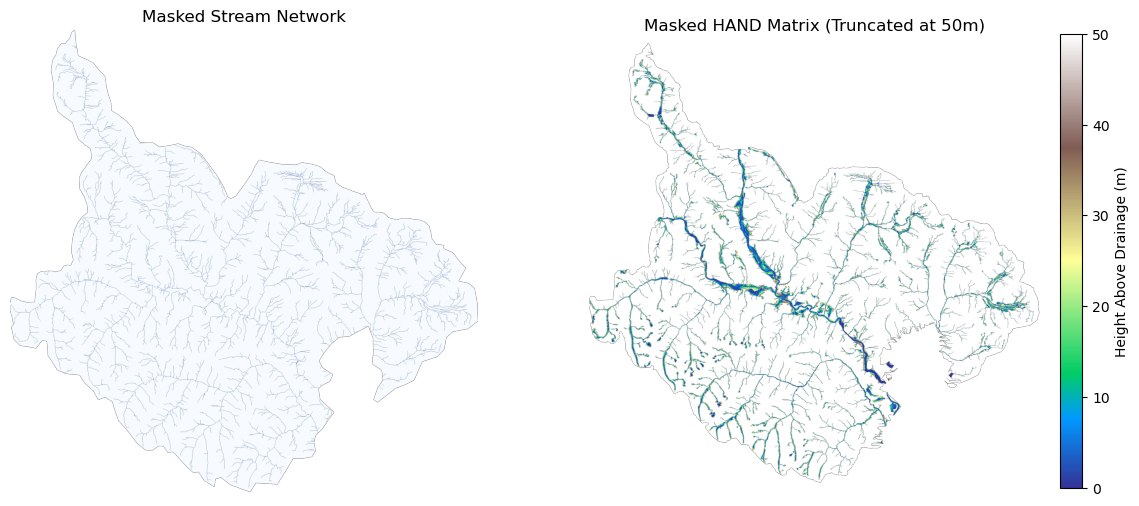

In [10]:
print("Computing HAND matrix...")
# Because stream_network is still a smart Raster, this will execute flawlessly.
hand = grid.compute_hand(fdir, inflated_dem, stream_network, dirmap=dirmap)

# 1. Write the clean, smart Rasters directly to disk FIRST.
grid.to_raster(stream_network, STREAM_OUT_PATH)
grid.to_raster(hand, HAND_OUT_PATH)
print("Outputs successfully written to disk.")

# 2. Create disposable, dumb numpy arrays purely for Matplotlib rendering.
# We inject NaNs here so the NoData void plots as pure white space.
plot_stream = np.where(valid_mask, stream_network, np.nan)
plot_hand = np.where(valid_mask, hand, np.nan)

# Inline Visual Verification
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(plot_stream, cmap="Blues")
ax[0].set_title("Masked Stream Network")
ax[0].axis("off")

# Using np.nanmax safely ignores the NaNs in the plotting array
im = ax[1].imshow(plot_hand, cmap="terrain", vmax=50) 
ax[1].set_title("Masked HAND Matrix (Truncated at 50m)")
ax[1].axis("off")
fig.colorbar(im, ax=ax[1], label="Height Above Drainage (m)", fraction=0.046, pad=0.04)

plt.show()